# K-Means Clustering for Customer Segmentation

In [1]:
import pandas as pd, numpy as np
import seaborn as sns, matplotlib.pyplot as plt
# Suppress all warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
customer_df = pd.read_csv('Online+Retail.csv', encoding='ISO-8859-1')
customer_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


In [3]:
customer_df.tail(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541899,581587,22726,ALARM CLOCK BAKELIKE GREEN,4,09-12-2011 12:50,3.75,12680.0,France
541900,581587,22730,ALARM CLOCK BAKELIKE IVORY,4,09-12-2011 12:50,3.75,12680.0,France
541901,581587,22367,CHILDRENS APRON SPACEBOY DESIGN,8,09-12-2011 12:50,1.95,12680.0,France
541902,581587,22629,SPACEBOY LUNCH BOX,12,09-12-2011 12:50,1.95,12680.0,France
541903,581587,23256,CHILDRENS CUTLERY SPACEBOY,4,09-12-2011 12:50,4.15,12680.0,France
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,09-12-2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,09-12-2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,09-12-2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,09-12-2011 12:50,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,09-12-2011 12:50,4.95,12680.0,France


In [4]:
customer_df.shape

(541909, 8)

In [5]:
customer_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


### Data Cleaning

In [6]:
#calculating null value percentage in each column
round(customer_df.isnull().mean() * 100, 2)

InvoiceNo       0.00
StockCode       0.00
Description     0.27
Quantity        0.00
InvoiceDate     0.00
UnitPrice       0.00
CustomerID     24.93
Country         0.00
dtype: float64

In [7]:
#dropping rows with missing customer values
customer_df = customer_df.dropna()
customer_df.shape

(406829, 8)

## Data Preparation

### RFM Analysis

In [8]:
#'Monetary' analysis
customer_df['Amount'] = customer_df['Quantity'] * customer_df['UnitPrice']

In [9]:
#group customers based on CustomerID and calculate sum of their purchases (Amount)
grouped = customer_df.groupby('CustomerID')[['Amount']].sum()
#resetting index
grouped = grouped.reset_index()
grouped.head()

,CustomerID,Amount
0,12346.0,0.00
1,12347.0,4310.00
2,12348.0,1797.24
3,12349.0,1757.55
4,12350.0,334.40


In [10]:
#calculating 'Frequency'
frequency = customer_df.groupby('CustomerID')[['InvoiceNo']].count()
frequency = frequency.reset_index()
frequency.head()

,CustomerID,InvoiceNo
0,12346.0,2
1,12347.0,182
2,12348.0,31
3,12349.0,73
4,12350.0,17


In [11]:
#changing names of columns
frequency.columns = ['CustomerID', 'Frequency']
frequency.head()

,CustomerID,Frequency
0,12346.0,2
1,12347.0,182
2,12348.0,31
3,12349.0,73
4,12350.0,17


In [12]:
#calculating 'Recency'
customer_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Amount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom,20.34


In [13]:
customer_df['InvoiceDate'] = pd.to_datetime(customer_df['InvoiceDate'], format='%d-%m-%Y %H:%M')
customer_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Amount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [14]:
customer_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    406829 non-null  object        
 1   StockCode    406829 non-null  object        
 2   Description  406829 non-null  object        
 3   Quantity     406829 non-null  int64         
 4   InvoiceDate  406829 non-null  datetime64[ns]
 5   UnitPrice    406829 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      406829 non-null  object        
 8   Amount       406829 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 31.0+ MB


In [15]:
#computing max date
max_date = max(customer_df['InvoiceDate'])
print(max_date)

2011-12-09 12:50:00


In [16]:
#computing difference between max date and transaction date
customer_df['time_diff'] = max_date - customer_df['InvoiceDate']
customer_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Amount,time_diff
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,373 days 04:24:00
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,373 days 04:24:00
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,373 days 04:24:00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,373 days 04:24:00
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,373 days 04:24:00


In [17]:
recency = customer_df.groupby('CustomerID')[['time_diff']].min()
recency = recency.reset_index()
recency.head()

,CustomerID,time_diff
0,12346.0,325 days 02:33:00
1,12347.0,1 days 20:58:00
2,12348.0,74 days 23:37:00
3,12349.0,18 days 02:59:00
4,12350.0,309 days 20:49:00


In [18]:
#merging R,F,M together
grouped = pd.merge(frequency, grouped, on='CustomerID', how='inner')
grouped.head()

,CustomerID,Frequency,Amount
0,12346.0,2,0.00
1,12347.0,182,4310.00
2,12348.0,31,1797.24
3,12349.0,73,1757.55
4,12350.0,17,334.40


In [19]:
grouped = pd.merge(recency, grouped, on='CustomerID', how='inner')
grouped.head()

,CustomerID,time_diff,Frequency,Amount
0,12346.0,325 days 02:33:00,2,0.00
1,12347.0,1 days 20:58:00,182,4310.00
2,12348.0,74 days 23:37:00,31,1797.24
3,12349.0,18 days 02:59:00,73,1757.55
4,12350.0,309 days 20:49:00,17,334.40


In [20]:
grouped.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']
grouped.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,325 days 02:33:00,2,0.00
1,12347.0,1 days 20:58:00,182,4310.00
2,12348.0,74 days 23:37:00,31,1797.24
3,12349.0,18 days 02:59:00,73,1757.55
4,12350.0,309 days 20:49:00,17,334.40


In [21]:
grouped['Recency'] = grouped['Recency'].dt.days
grouped.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,325,2,0.00
1,12347.0,1,182,4310.00
2,12348.0,74,31,1797.24
3,12349.0,18,73,1757.55
4,12350.0,309,17,334.40


### Outlier Analysis

<Axes: >

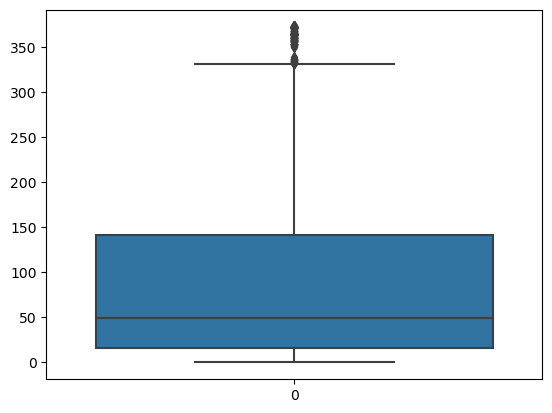

In [22]:
sns.boxplot(grouped['Recency'])

<Axes: >

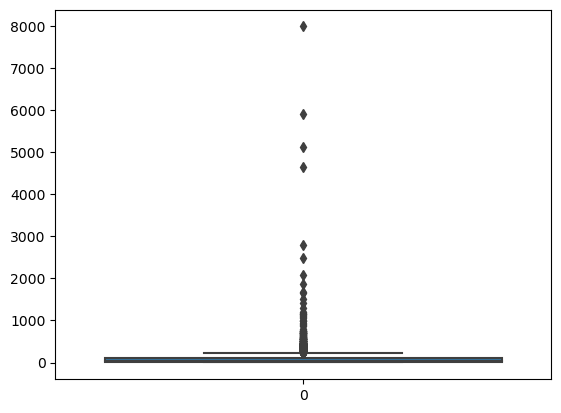

In [23]:
sns.boxplot(grouped['Frequency'])

<Axes: >

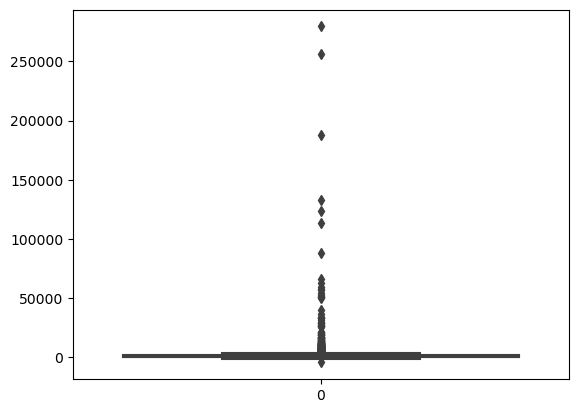

In [24]:
sns.boxplot(grouped['Monetary'])

### Rescaling

In [25]:
from sklearn.preprocessing import StandardScaler

In [26]:
grouped.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,325,2,0.00
1,12347.0,1,182,4310.00
2,12348.0,74,31,1797.24
3,12349.0,18,73,1757.55
4,12350.0,309,17,334.40


In [27]:
rfm_df = grouped[['Recency','Frequency','Monetary']]
rfm_df.head()

,Recency,Frequency,Monetary
0,325,2,0.00
1,1,182,4310.00
2,74,31,1797.24
3,18,73,1757.55
4,309,17,334.40


In [28]:
scaler = StandardScaler()
rfm_df_scaled = scaler.fit_transform(rfm_df)
rfm_df_scaled

array([[ 2.32202285, -0.3917197 , -0.23100099],
       [-0.89373323,  0.38265697,  0.29343167],
       [-0.1691956 , -0.26695902, -0.01231622],
       ...,
       [-0.83418219, -0.34439668, -0.20951263],
       [-0.87388289,  2.85205812,  0.02390005],
       [-0.48680114, -0.0991774 , -0.00744423]])

In [29]:
rfm_df_scaled = pd.DataFrame(rfm_df_scaled)
rfm_df_scaled.head()

,0,1,2
0,2.322023,-0.391720,-0.231001
1,-0.893733,0.382657,0.293432
2,-0.169196,-0.266959,-0.012316
3,-0.725005,-0.086271,-0.017146
4,2.163220,-0.327188,-0.190312


In [30]:
rfm_df_scaled.columns = ['Recency','Frequency','Monetary']

In [31]:
rfm_df_scaled.head()

,Recency,Frequency,Monetary
0,2.322023,-0.391720,-0.231001
1,-0.893733,0.382657,0.293432
2,-0.169196,-0.266959,-0.012316
3,-0.725005,-0.086271,-0.017146
4,2.163220,-0.327188,-0.190312


## Modeling

In [32]:
from sklearn.cluster import KMeans
#initializing a blank list for Within-Cluster-Sum-of-Squares distances for various values of K
WCSS = []

### Elbow Method

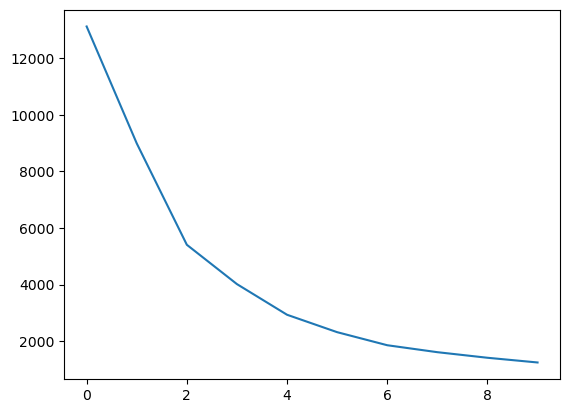

In [33]:
for i in range (1,11):
    kmeans = KMeans(n_clusters=i, max_iter=50)
    kmeans.fit(rfm_df_scaled)
    WCSS.append(kmeans.inertia_)
plt.plot(WCSS)

#### We can see that the 'Elbow point' is at 2 clusters, but since from a business point of view it might not be very efficient, the next best choice is to go ahead with 3 or 5 clusters.

### Silhouette Score Method

In [34]:
from sklearn.metrics import silhouette_score

In [35]:
for i in range(2,11):
    kmeans = KMeans(n_clusters=i, max_iter=50)
    kmeans.fit(rfm_df_scaled)
    cluster_labels = kmeans.labels_
    silhouette_avg = silhouette_score(rfm_df_scaled, cluster_labels)
    print("For {0} clusters, the silhouette score is: {1}".format(i, silhouette_avg))

For 2 clusters, the silhouette score is: 0.9344641162235822
For 3 clusters, the silhouette score is: 0.6003883114752382
For 4 clusters, the silhouette score is: 0.5976040206171828
For 5 clusters, the silhouette score is: 0.6160117259955692
For 6 clusters, the silhouette score is: 0.5919300618934865
For 7 clusters, the silhouette score is: 0.5238467453014489
For 8 clusters, the silhouette score is: 0.5012060818072126
For 9 clusters, the silhouette score is: 0.5093073508589394
For 10 clusters, the silhouette score is: 0.41094488960176395


#### We can see that the silhouette score is highest for 2 clusters, but since from a business point of view, it might not be very efficient, the next best choice is to go ahead with 3 or 5 clusters.